In [18]:
#week 1 : rolling feature  & signal processing

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
df= pd.read_csv("../data/ai4i2020.csv", on_bad_lines='skip')
print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [21]:
print(df. describe())

               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.033900   
std                179.284096      9.968934        63.654147         0.180981   
min               1168.000000      3.800000         0.000000   

In [22]:
## dataset information
#- 10,000 rows and 14 columns
-#null values: 0

SyntaxError: invalid syntax (2040256002.py, line 3)

In [24]:
print(df["Machine failure"].value_counts())
print(df[["Air temperature [K]", "Torque [Nm]"]].corr())

Machine failure
0    9661
1     339
Name: count, dtype: int64
                     Air temperature [K]  Torque [Nm]
Air temperature [K]             1.000000    -0.013778
Torque [Nm]                    -0.013778     1.000000


In [ ]:
plt.figure(figsize=(8,4))
df["Tool wear [min]"].hist(bins=30, color="orange")
plt.title("Tool Wear Distribution")
plt.savefig("toolwear_dist.png")
plt.show()

In [ ]:
sensor_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for col in sensor_cols:
    for w in [5, 10]:
        df[f"{col}_rollmean_{w}"] = df[col].rolling(window=w, min_periods=1).mean()
        df[f"{col}_rollstd_{w}"]  = df[col].rolling(window=w, min_periods=1).std().fillna(0)
        df[f"{col}_rollvar_{w}"]  = df[col].rolling(window=w, min_periods=1).var().fillna(0)

print("Total Features:", df.shape[1])
df.head()

Total Features: 44


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,...,Torque [Nm]_rollvar_5,Torque [Nm]_rollmean_10,Torque [Nm]_rollstd_10,Torque [Nm]_rollvar_10,Tool wear [min]_rollmean_5,Tool wear [min]_rollstd_5,Tool wear [min]_rollvar_5,Tool wear [min]_rollmean_10,Tool wear [min]_rollstd_10,Tool wear [min]_rollvar_10
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,...,0.000000,42.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,...,6.125000,44.550000,2.474874,6.125000,1.500000,2.121320,4.500000,1.500000,2.121320,4.500000
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,...,10.903333,46.166667,3.302020,10.903333,2.666667,2.516611,6.333333,2.666667,2.516611,6.333333
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,...,18.380000,44.500000,4.287190,18.380000,3.750000,2.986079,8.916667,3.750000,2.986079,8.916667
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,...,17.835000,43.600000,4.223150,17.835000,4.800000,3.492850,12.200000,4.800000,3.492850,12.200000


In [ ]:
for col in sensor_cols:
    print(f"{col}: {df[col].var():.4f}")

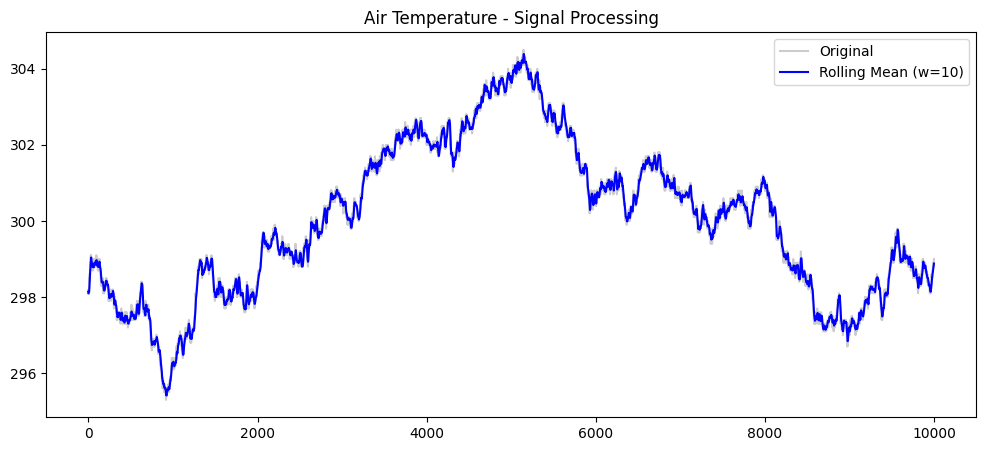

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df["Air temperature [K]"], alpha=0.4, label="Original", color="gray")
plt.plot(df["Air temperature [K]_rollmean_10"], label="Rolling Mean (w=10)", color="blue")
plt.title("Air Temperature - Signal Processing")
plt.legend()
plt.savefig("rolling_plot.png")
plt.show()

In [ ]:
df.to_csv("../data/week1_features.csv", index=False)
print("Saved: week1_features.csv")

Saved: week1_features.csv
